
 Recorded Time: 5.038723945617676

number of frames: 10
# Frame OK ...

file size is: 122796560
Size check failed ...    
SNR:  11.933330297470093
Best match found at index 26 with average vote score 15.0
Best match found at index 78 with average vote score 15.0
index:  (221, 5013)
msg:    ÿÿÿÿÿÿÿÿð   ?ÿÿÿ ÿü ÿõF2ÖW76vR2FRFVfVÇBÆöBf÷"FRFW7G2ÂæB2#B&G2ÆöærâBvÆÂ&R7WW'÷6VBvF


FileNotFoundError: [Errno 2] No such file or directory: 'msg: 1024 code_rate: 0.33.txt'

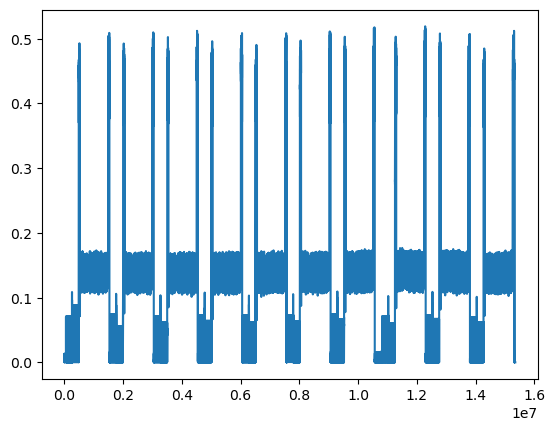

In [5]:
import pymongo.collection
import uhd, time, config, os
from operator import itemgetter
from itertools import groupby
import scipy.signal 
import numpy as np
import pymongo
import datetime 
import copy
import channelCoding as cc
import hmac
import bson
import queue

import matplotlib.pyplot as plt


class FiFo:
    def __init__(self, maxsize = 10000):
        self.maxsize = maxsize  
        self.q = queue.Queue(maxsize=maxsize)

    def push(self, item):
        if self.q.qsize() < self.q.maxsize:
            self.q.put_nowait(item)
        else:
            self.q.get()
            self.q.put_nowait(item)
    
    def return_concat_queue(self):
        return np.concatenate(list(self.q.queue)[0:100])

class RX:
    def __init__(self, qu: FiFo = FiFo(maxsize = 10000), conf:config.CONFIG = config.CONFIG(), usrp:uhd.usrp.MultiUSRP = uhd.usrp.MultiUSRP(args="serial=8000182")):
        self.qu = qu
        self.conf = conf
        self.usrp = usrp

    def _config_streamer(self,chnls,spp = None):
        st_args = uhd.usrp.StreamArgs("fc32", "sc16")
        st_args.channels = chnls
        # st_args.args = "spp="+str(spp)
        streamer = self.usrp.get_rx_stream(st_args)
        return streamer

    def _batch_init(self,streamer,batch_size = None):
        if batch_size is None:
            batch_size = streamer.get_max_num_samps()
        nr_batches= int(self.conf.ACQ_TIME * self.conf.RX_RATE / batch_size)
        return batch_size, nr_batches

    def _start_stream(self,streamer,batch_size):
        stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.start_cont)
        stream_cmd.num_samps = batch_size
        stream_cmd.stream_now = False  
        stream_cmd.time_spec = uhd.types.TimeSpec(self.usrp.get_time_now().get_real_secs() + 0.05)   
        streamer.issue_stream_cmd(stream_cmd)

    def _stop_stream(self,streamer,recv_buffer):
        metadata = uhd.types.RXMetadata()
        stream_cmd = uhd.types.StreamCMD(uhd.types.StreamMode.stop_cont)
        streamer.issue_stream_cmd(stream_cmd)
        while streamer.recv(recv_buffer, metadata):
            pass



    def record(self):
        self.usrp.set_time_now(uhd.types.TimeSpec(0.0)) # this should work well for syncing the MIMO channel

        streamer = self._config_streamer( chnls=self.conf.CHANNEL,spp=None)
        batch_size, nr_batches = self._batch_init(streamer=  streamer, batch_size= None)
        recv_buffer = np.zeros((len(self.conf.CHANNEL), batch_size), dtype=np.complex64)
        metadata = uhd.types.RXMetadata()

        for chnl in self.conf.CHANNEL:
            self.usrp.set_rx_rate(self.conf.RX_RATE, chnl)
            self.usrp.set_rx_freq(uhd.libpyuhd.types.tune_request(self.conf.FREQ), chnl)
            if self.conf.RX_GAIN != "agc":
                self.usrp.set_rx_gain(self.conf.RX_GAIN, chnl)
        if self.conf.RX_GAIN == "agc":
            self.usrp.set_rx_agc(True, 0)
            print("AGC is enabled")

        self._start_stream(streamer = streamer,batch_size= batch_size)
        

        #updating file name if mimo
        if self.conf.MIMO:
            file1 = "_"+str(np.round(self.usrp.get_rx_freq(),2))+"_"+str(np.round(self.usrp.get_rx_rate(),2))+"_"+str(self.conf.RX_GAIN)+"_"+str(self.conf.ACQ_TIME) + "_"+ str(self.conf.IN_CHAMBER)+"_1.iq"
            file2 = "_"+str(np.round(self.usrp.get_rx_freq(),2))+"_"+str(np.round(self.usrp.get_rx_rate(),2))+"_"+str(self.conf.RX_GAIN)+"_"+str(self.conf.ACQ_TIME) + "_"+ str(self.conf.IN_CHAMBER)+"_2.iq"
            f1 = open(file1,"wb")
            f2 = open(file2,"wb")

            start = time.time()
            for i in range(nr_batches):
                streamer.recv(recv_buffer, metadata)
                # np.zeros(1).tofile(f)
                recv_buffer[0].tofile(f1)
                recv_buffer[1].tofile(f2)
            duration = time.time() - start
            print("\n Recorded Time: " + str(duration))
            # Stop Stream
            self._stop_stream(streamer=streamer, recv_buffer=recv_buffer)
            f1.close()
            f2.close()
            return streamer, file1, file2

        else:
            file = "_"+str(np.round(self.usrp.get_rx_freq(),2))+"_"+str(np.round(self.usrp.get_rx_rate(),2))+"_"+str(self.conf.RX_GAIN)+"_"+str(self.conf.ACQ_TIME) + "_"+ str(self.conf.IN_CHAMBER)+"_.iq"
            f = open(file,"wb")
            new_frame_detected = False
            start = time.time()
            cnt = 4
            for i in range(nr_batches):
                streamer.recv(recv_buffer, metadata)
                self.qu.push(recv_buffer[0])
                # recv_buffer[0] = self.butter(recv_buffer[0], cutoff=0.5, Fs=self.conf.RX_RATE)
                fft = np.abs(np.fft.fft(recv_buffer[0]))
                if np.sum(
                    np.concatenate(
                                [
                                fft[1:int(self.conf.FREQ_DEVIATION_PRECENTAGE*len(fft))], 
                                fft[int(1-self.conf.FREQ_DEVIATION_PRECENTAGE*batch_size):]
                                ]
                            )
                        ) > 1.4*2*self.conf.FREQ_DEVIATION_PRECENTAGE*np.sum(fft[int(self.conf.FREQ_DEVIATION_PRECENTAGE*batch_size): int(1-self.conf.FREQ_DEVIATION_PRECENTAGE*batch_size)]):
                    
                    if not new_frame_detected:
                        new_frame_detected = True
                        np.zeros(batch_size).tofile(f)
                        self.qu.return_concat_queue().tofile(f)
                        np.zeros(batch_size//2).tofile(f)
                    
                    recv_buffer[0].tofile(f) 

                    cnt = 0   
                else:
                    if (cnt:=cnt+1) < self.conf.LINIENT:
                       recv_buffer[0].tofile(f)  
                    else:
                        new_frame_detected = False
                        np.zeros(10).tofile(f)

                

            duration = time.time() - start
            print("\n Recorded Time: " + str(duration))
            # Stop Stream
            self._stop_stream(streamer=streamer, recv_buffer=recv_buffer)
            f.close()
            return file
    
        








class Demodulation:
    def __init__(self, conf:config.CONFIG = config.CONFIG()):
        self.conf = conf
        
    def butter(self,input):
        fltr = scipy.signal.butter(30, self.conf.LPF_CUTOFF, 'low', analog=False, output='sos',fs=self.conf.RX_RATE)
        return scipy.signal.sosfilt(fltr, input) 

    def fft_max_peak(self, frame,window):
        fft = np.fft.fftshift(np.fft.fft(frame[:window]))
        peak = np.argmax(np.abs(fft))
        return peak,fft
    
    def decision(self, peak, threshold):
        return 0 if peak < threshold else 1
    
    def llr_from_fft(self, fft):
        E_f1 = np.sum(np.power(np.abs(fft[len(fft)//2 - int(len(fft)*self.conf.FREQ_DEVIATION_PRECENTAGE)]),1))
        E_f2 = np.sum(np.power(np.abs(fft[len(fft)//2 + int(len(fft)*self.conf.FREQ_DEVIATION_PRECENTAGE)]),1))
        # llr for BFSK modulation is given by the following formula
        return (E_f1-E_f2)


    def decode(self, frame):
    # compute sliding fft of the signal every 40 samples where the peak is 1 and the rest 0
        res= []
        llr = []
        window = slide = self.conf.WINDOW
        # lpf
        frame = self.butter(frame)
        
        # res.append(self.decision(peak = peak, threshold=window//2))
        for i in range(0,len(frame),slide):
            peak,fft  = self.fft_max_peak(frame[i:i+window],window)
            res.append(self.decision(peak=peak, threshold=window//2))
            llr.append(self.llr_from_fft(fft))
        return res, llr


    def decode_repetition_code(self, received, repeat):
        """
        Decodes a repetition-coded sequence by applying majority voting and calculates vote scores.
        """
        decoded = []
        scores = []
        for i in range(0, len(received), repeat):
            chunk = received[i:i+repeat]
            if len(chunk) == repeat:
                vote_score = max(chunk.count(0), chunk.count(1))  # Majority vote score
                decoded.append(int(np.round(np.mean(chunk))))
                scores.append(vote_score)
        return decoded, scores

    def find_best_sequence(self, received, known_seq, repeat):
        """
        Finds the best matching sequence in the received repetition-coded data based on the highest vote score.
        """
        best_index = -1
        best_score = -1
        best_match = []
        cnt = 0
        while len(received) >= repeat * len(known_seq):
            decoded, scores = self.decode_repetition_code(received, repeat)
            window = decoded[:len(known_seq)]
            avg_score = np.mean(scores[:len(known_seq)])
            
            if window == known_seq and avg_score > best_score:
                best_index = cnt
                best_score = avg_score
                best_match = window
            
            received = received[1:]  # Slide one step forward
            cnt += 1
        
        if best_index != -1:
            print(f"Best match found at index {best_index} with average vote score {best_score}")
            return best_index
        else:
            print("Known sequence not found")
            return None

    def detect_message_indices(self,received, preamble, repeat, cooefficient=2):
        preamble = preamble
        received_start = self.find_best_sequence(received[:len(preamble)*cooefficient], preamble[::repeat], repeat)
        received_end = self.find_best_sequence(received[-cooefficient*len(preamble):], preamble[::repeat], repeat)
        if received_start is None or received_end is None:
            return None, None
        return received_start + len(preamble), received_end + len(received)-(cooefficient*len(preamble))

    def get_llr(self, frame):
        res,llr = self.decode(frame)

        # try:
        index = self.detect_message_indices(received=res, preamble=self.conf.PREAMBLE, repeat=self.conf.PREAMBLE_REPEAT)
        print("index: ", index)

        if index[0] is None:
            print("premable not found!")
            return None, None, None, None
            
        frame = frame[index[0]:index[1]]
        # msg_scale = cc.pick_bg2_file_for_Z()
        # mac_scale = int(1/self.conf.MAC_CODE_RATE)
        llr_msg = llr[index[0]:index[1]]
        # llr_mac = llr[index[0]+4352:index[0]+4352+1088]
        llr_mac = None
        msg = res[index[0]:index[1]]
        mac = None
        # mac = res[index[0]+4352:index[0]+4352+1088]
        return msg, mac, llr_msg, llr_mac
    
    def soft_decision(self, llr, H_param):
        return cc.decode_llr(np.array(llr), H_param)[0]
    def ldpc_decode(self, llr_msg, llr_mac):
        msg_H_param = cc.get_5G_ldpc_params("msg: 1024 code_rate: "+str(np.round(self.conf.MSG_CODE_RATE,2))+".txt")
        mac_H_param = cc.get_5G_ldpc_params("msg: 256 code_rate: "+str(np.round(self.conf.MAC_CODE_RATE,2))+".txt")

        try:
            msg = self.soft_decision(llr_msg, H_param=msg_H_param)
        except:
            msg = None
        try:
            mac = self.soft_decision(llr_mac, H_param=mac_H_param)
        except:
            mac = None

        return msg, mac





class PostProcessing:
    def __init__(self,  file:str, conf:config.CONFIG = config.CONFIG(), demod:Demodulation = Demodulation()):
        self.file = file
        self.conf = conf
        self.demod = demod

        self.IQsamples = np.fromfile(file, np.complex64)
        self.TotalFramesIndex, self.TotalNoiseIndex = self.frameFinder(self.IQsamples)


        # self.zeroRemover(samples=self.IQsamples,framesIndex=framesIndex)  
        # self.tindx = np.fromfile(self.file+".tindx", dtype=int, sep= ',')
        # self.tindx = self.tindx.reshape(-1,2)

        

    def __len__(self):
        return len(self.TotalFramesIndex)


    def frameByIndex(self,index):
        return self.IQsamples[index[0]:index[1]]
    def frameByNumber(self,frame_nr:int):
        return self.frameByIndex(self.TotalFramesIndex[frame_nr])
    
    def noiseByIndex(self,index):
        return self.IQsamples[index[0]:index[1]]
    def noiseByNumber(self,noise_nr:int):
        return self.noiseByIndex(self.TotalNoiseIndex[noise_nr])

    def frameFinder(self, samples):
        plt.plot(np.abs(samples))
        test_list = np.nonzero(samples)
        noise_index = []
        framesIndex = []

        for k, g in groupby(enumerate(test_list[0]), lambda ix: ix[0]-ix[1]):
            temp = list(map(itemgetter(1), g))
            if len(temp)==204000: #hard coded but must be changed
                noise_index.append([temp[0],temp[-1]])
                continue
            elif len(temp)< self.conf.MIN_FRAME_SIZE:
                continue
            framesIndex.append([temp[0],temp[-1]])


        return np.array(framesIndex), np.array(noise_index)

    # def zeroRemover(self, samples, framesIndex):
    #     f = open(self.file,"wb")
    #     f_time_index= open(self.file+".tindx","wb")

    #     framesIndex.tofile(f_time_index,sep= ',')
    #     for i,j in framesIndex:
    #         frame = samples[i:j]
    #         frame.tofile(f)
    #         np.zeros(2,dtype=np.complex64).tofile(f)

    #     f.close()
    #     f_time_index.close()

    def check(self): 
        #check minimum number of the frames
        ok = True
        nr_frame = len(self.TotalFramesIndex)
        print("\nnumber of frames: " + str(nr_frame))
        if  nr_frame < self.conf._minFrames or  nr_frame > self.conf._maxFrames:
            print("# Frame check failed ...")
            ok = False
        else:
            print("# Frame OK ...")
        # Check the file size
        size = os.path.getsize(self.file)
        print("\nfile size is: " + str(os.path.getsize(self.file)))
        if size < self.conf._minSize or size > self.conf._maxSize:
            print("Size check failed ...    ")
        else:
            print("Size OK .")
        return ok
    

    def bits_to_string(self, bit_list):
        chars = []
        for i in range(0, len(bit_list), 8):
            byte_bits = bit_list[i:i+8]
            if len(byte_bits) < 8:
                break
            val = 0
            for b in byte_bits:
                val = (val << 1) | b
            chars.append(chr(val))
        return "".join(chars)
    
    def binary_list_to_hex(self, binary_list):
        # Ensure the length of the list is a multiple of 4
        if len(binary_list) % 4 != 0:
            raise ValueError("The length of the binary list must be a multiple of 4.")
        
        # Group into chunks of 4 bits and convert to hex
        hex_string = ''.join(
            hex(int(''.join(map(str, binary_list[i:i+4])), 2))[2:]  # Convert binary to hex and remove "0x"
            for i in range(0, len(binary_list), 4)
        )
        return hex_string.lower()  # Convert to uppercase if desired


    
    def push_to_db(self, collection: pymongo.collection.Collection):
        for indx in range(len(self.TotalFramesIndex)):
            insert_data = copy.deepcopy(self.conf.config)
            insert_data["TIME"] =  datetime.datetime.now()

            frame = self.frameByNumber(indx)
            I = np.array(np.real(frame)).tobytes()
            Q = np.array(np.imag(frame)).tobytes()
            insert_data['I'], insert_data['Q'] = bson.binary.Binary(I), bson.binary.Binary(Q)
 
            noise = self.noiseByNumber(indx)
            noise_I = np.array(np.real(noise)).tobytes()
            noise_Q = np.array(np.imag(noise)).tobytes()
            insert_data['noise_I'] , insert_data['noise_Q'] = bson.binary.Binary(noise_I), bson.binary.Binary(noise_Q)

            insert_data['dtype'] = 'float'
            insert_data['shape'] = frame.shape

            insert_data['noise_power'] = np.average(np.abs(noise)**2)
            
            # calculate the frame power avoiding the preamble
            payload = frame[int(len(self.conf.PREAMBLE)*self.conf.PREAMBLE_REPEAT*self.conf.TX_SPS * 2) : int(-1*len(self.conf.PREAMBLE)*self.conf.PREAMBLE_REPEAT*self.conf.TX_SPS * 2)]
            insert_data['frame_power'] = np.average(np.abs(payload)**2)

            SNR = 10*np.log10(insert_data['frame_power']/insert_data['noise_power'])
            insert_data['SNR'] = SNR
            print("SNR: ", SNR)



            msg, mac, msg_llr, mac_llr = self.demod.get_llr(frame)
  
            if msg_llr is None:
                print("preamble not found!")
                insert_data['error'] = 'premable not found!'
                collection.insert_one(insert_data)
                continue
            insert_data['msg_hard_decision'] = self.bits_to_string(msg[0:1024])
            print("msg: ", insert_data['msg_hard_decision'])
            # insert_data['mac_hard_decision'] = self.binary_list_to_hex(mac[0:256])
            # insert_data['success_verification'] = hmac.new(self.conf.MAC_KEY.encode('utf-8'), msg=insert_data['msg_hard_decision'].encode('utf-8'), digestmod='sha256').hexdigest() == insert_data['mac_hard_decision']


            # insert_data['llr_msg'] = msg_llr
            # insert_data['llr_mac'] = mac_llr

            msg, mac = self.demod.ldpc_decode(msg_llr, mac_llr)
            if msg is None:
                insert_data['error'] = 'ldpc decoding failed!'
                collection.insert_one(insert_data)
                continue
            insert_data['rceived_msg_ldpc_string'] = self.bits_to_string(msg[0:1024])
            # insert_data['rceived_mac_ldpc_hex'] = self.binary_list_to_hex(mac[0:256])
            # insert_data['ldpc_success_verification'] = hmac.new(self.conf.MAC_KEY.encode('utf-8'), msg=insert_data['rceived_msg_ldpc_string'].encode('utf-8'), digestmod='sha256').hexdigest() == insert_data['rceived_mac_ldpc_hex']

            print(insert_data['rceived_msg_ldpc_string'])
            print('')
            collection.insert_one(insert_data)
        print("\nData pushed to the database ...")



### tests
def test():

    myclient = pymongo.MongoClient("mongodb://localhost:27017/")
    mydb = myclient["MAC_SUPERPOSITION"]

    rx = RX()
    files = rx.record()

    pp = PostProcessing(file=files)
    if(pp.check()):
        pp.push_to_db(collection = mydb['1D'])



if __name__ == "__main__":
    test()